# Heatmap

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 3, Finished, Available, Finished, False)

In [7]:
%run ./peak_plot

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 10, Finished, Available, Finished, True)

In [3]:
match_method = "calendar2_1year"

# =====================================================
# Load matching result
# =====================================================

matches = pd.read_parquet(
    f"/lakehouse/default/Files/output/matching_high/{match_method}/matches"
)

matches["cohort"] = pd.to_datetime(matches["adoption_month"]).dt.to_period("M")

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()

print(matches.head())
print(f"Treated IDs: {len(treated_ids)}")
print(f"Matched control IDs: {len(control_ids)}")


# =====================================================
# Load full monthly data
# IMPORTANT: keep this as full sample
# =====================================================

month_result_full = pd.read_parquet("/lakehouse/default/Files/month_data")

print("Full month_result:", month_result_full.shape)
print("Full households:", month_result_full["aID"].nunique())


# =====================================================
# Construct matched sample mapping
# =====================================================

treated_map = matches[["treated_id", "cohort"]].drop_duplicates().copy()
treated_map.columns = ["aID", "cohort"]
treated_map["treatment"] = 1

control_map = matches[["control_id", "cohort"]].copy()
control_map.columns = ["aID", "cohort"]
control_map["treatment"] = 0

match_map = pd.concat([treated_map, control_map], axis=0)

print(match_map.head())


# =====================================================
# Matched sample only
# Use this for main matched analysis
# =====================================================

month_result_matched = month_result_full.merge(
    match_map,
    on="aID",
    how="inner"
)

print("Matched month_result:", month_result_matched.shape)
print("Matched households:", month_result_matched["aID"].nunique())


# =====================================================
# Identify adopter / never adopter groups in full sample
# =====================================================

all_adopter_ids = month_result_full.loc[
    month_result_full["tariff_start"].notna(), "aID"
].unique()

all_never_ids = month_result_full.loc[
    month_result_full["tariff_start"].isna(), "aID"
].unique()

matched_never_ids = control_ids

unmatched_never_ids = np.setdiff1d(
    all_never_ids,
    matched_never_ids
)

print(f"All adopters: {len(all_adopter_ids)}")
print(f"All never adopters: {len(all_never_ids)}")
print(f"Matched never adopters: {len(matched_never_ids)}")
print(f"Unmatched never adopters: {len(unmatched_never_ids)}")


StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 5, Finished, Available, Finished, False)

           treated_id          control_id adoption_month  distance  valid_dim  \
0  735999166200137406  735999166201588467     2025-10-01  0.056840          5   
1  735999166200137406  735999166200200018     2025-10-01  0.056862          5   
2  735999166200137406  735999166202144495     2025-10-01  0.061165          5   
3  735999166200137406  735999166204733253     2025-10-01  0.061480          5   
4  735999166200137406  735999166202887996     2025-10-01  0.068502          5   

   match_rank   cohort  
0           1  2025-10  
1           2  2025-10  
2           3  2025-10  
3           4  2025-10  
4           5  2025-10  
Treated IDs: 1696
Matched control IDs: 7527
Full month_result: (4538578, 17)
Full households: 48930
                   aID   cohort  treatment
0   735999166200137406  2025-10          1
5   735999166200193587  2025-10          1
10  735999166200271612  2025-10          1
15  735999166200436967  2025-10          1
20  735999166200437223  2025-10          1
Match

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 6, Finished, Available, Finished, False)

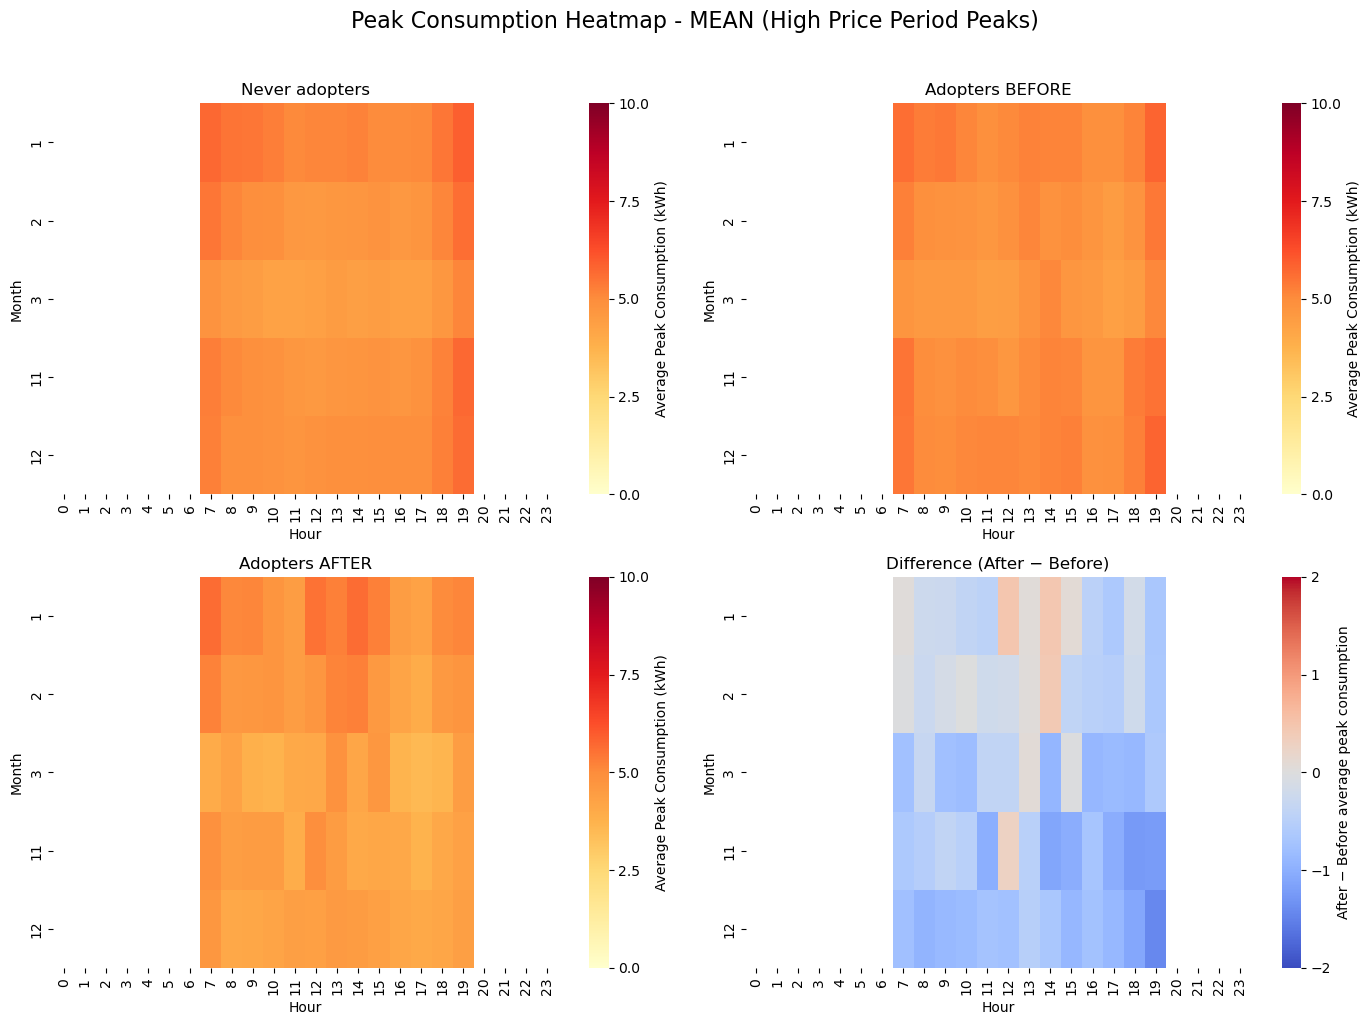

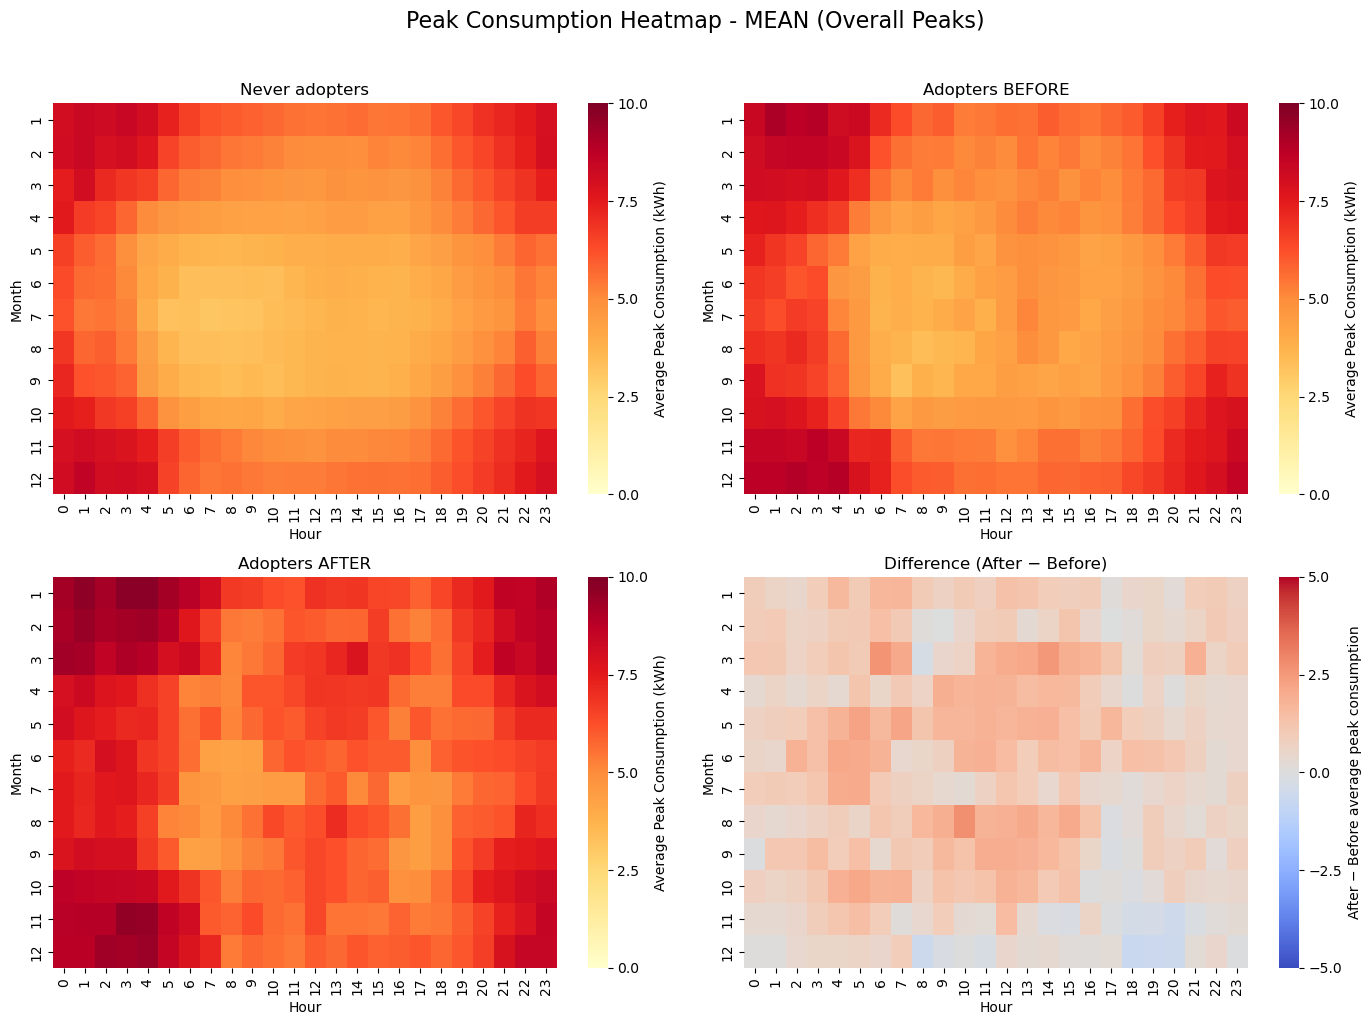

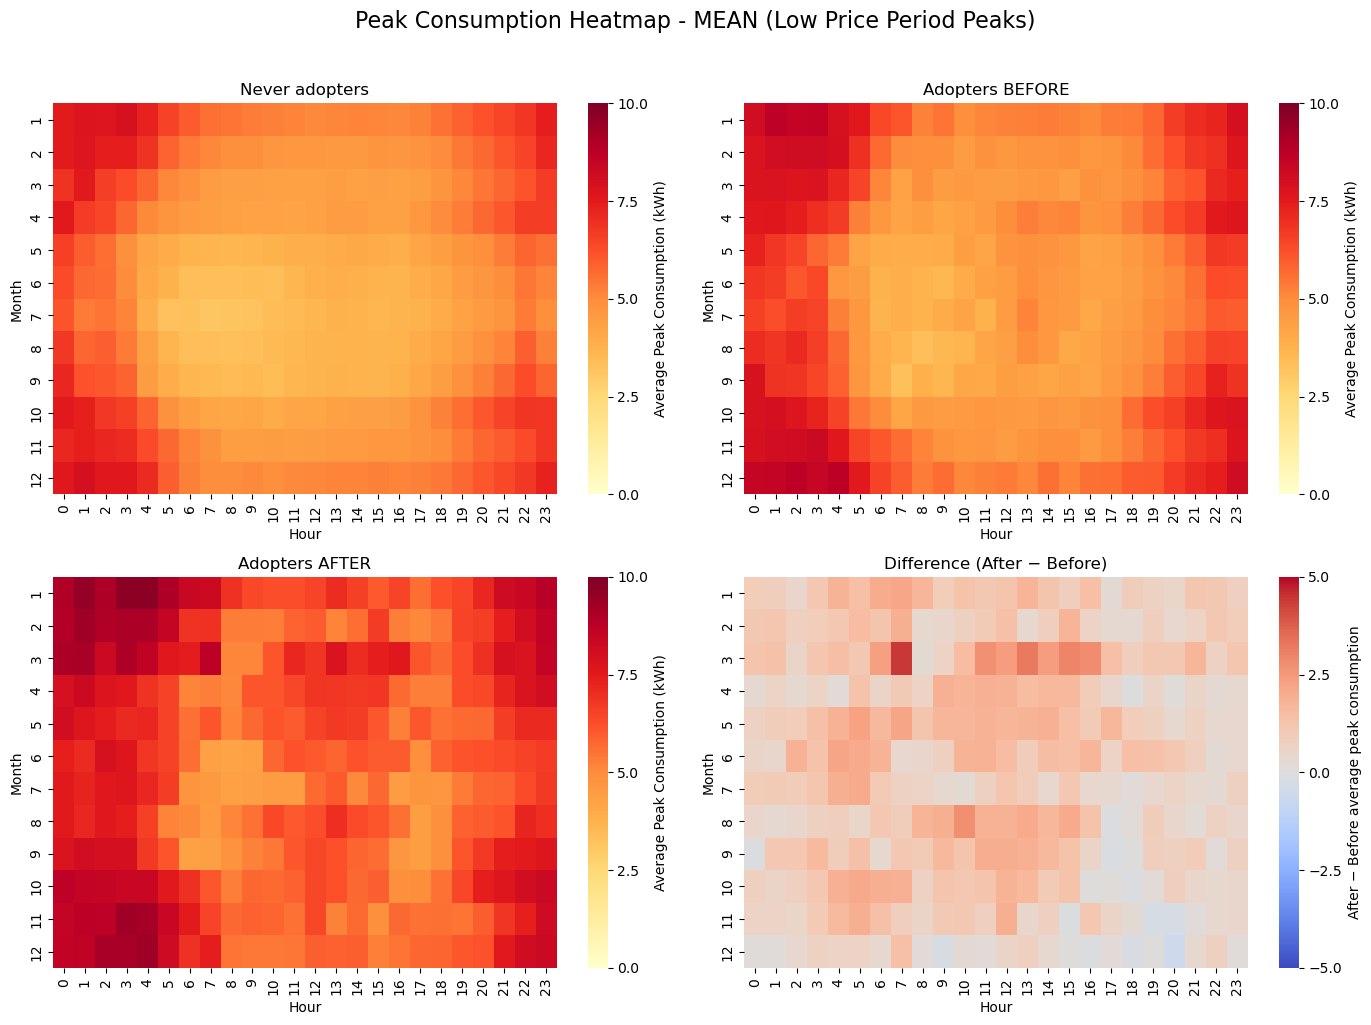

In [ ]:
# Peak consumption heatmap: E(consumption | peak hour)
# 當 peak 發生在這個 month-hour cell 時，平均有多大？

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "high"],
    price_label="high"
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "all"],
    price_label="all"
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "low"],
    price_label="low"
)

1×2
Everyone overall consumption (Before tariff)
Everyone overall consumption (After tariff)

1×4
All never adopters
All adopters (Before tarff)
Matched never adopters
Unmatched never adopters

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 7, Finished, Available, Finished, False)

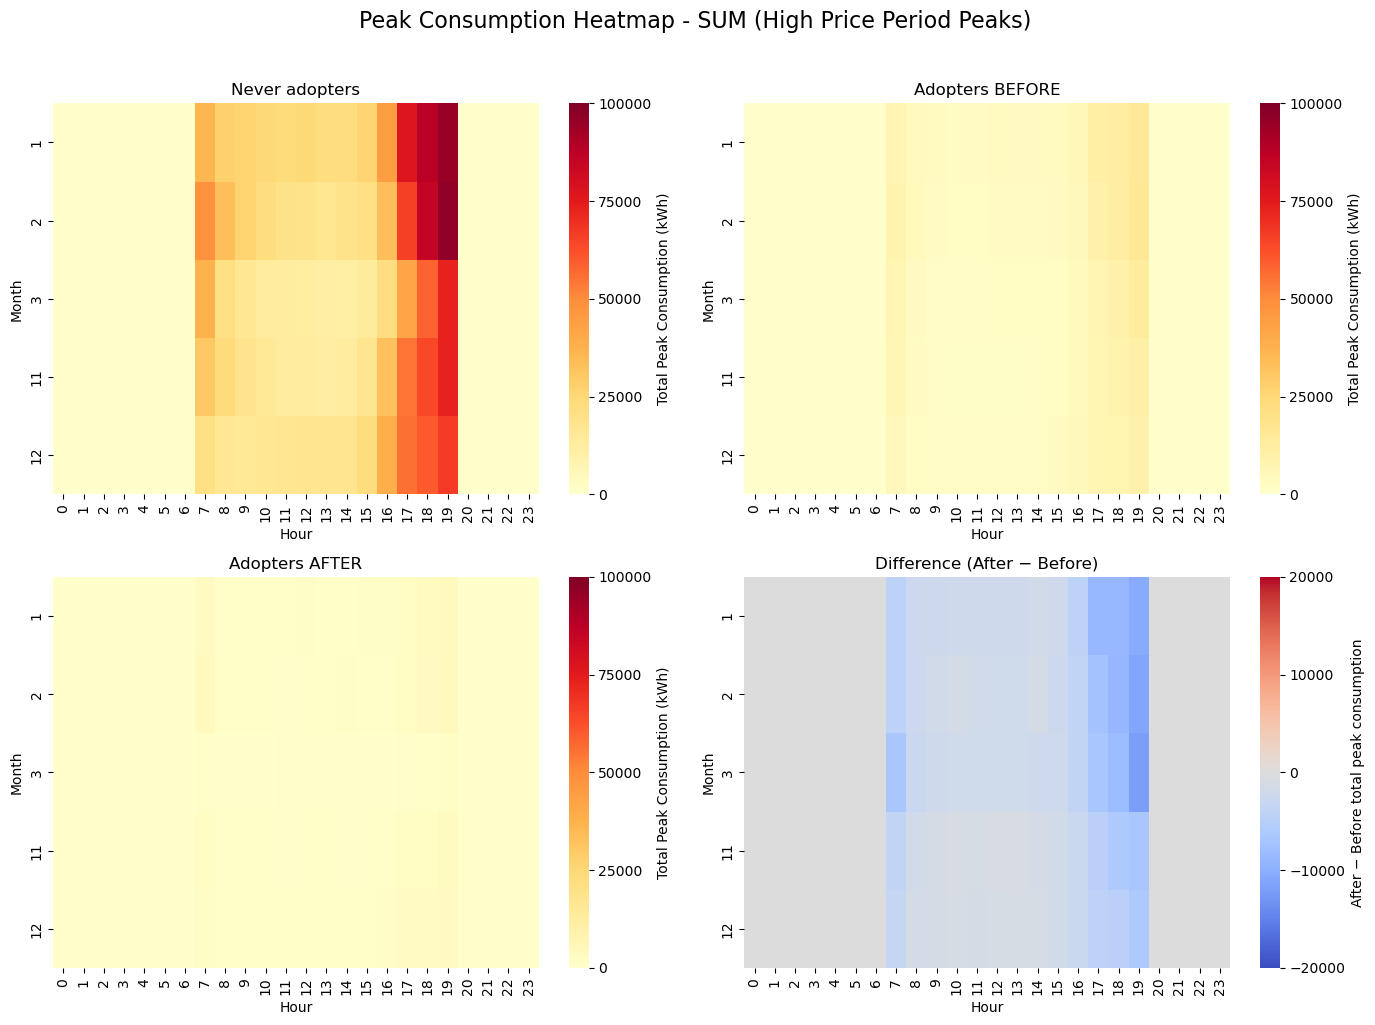

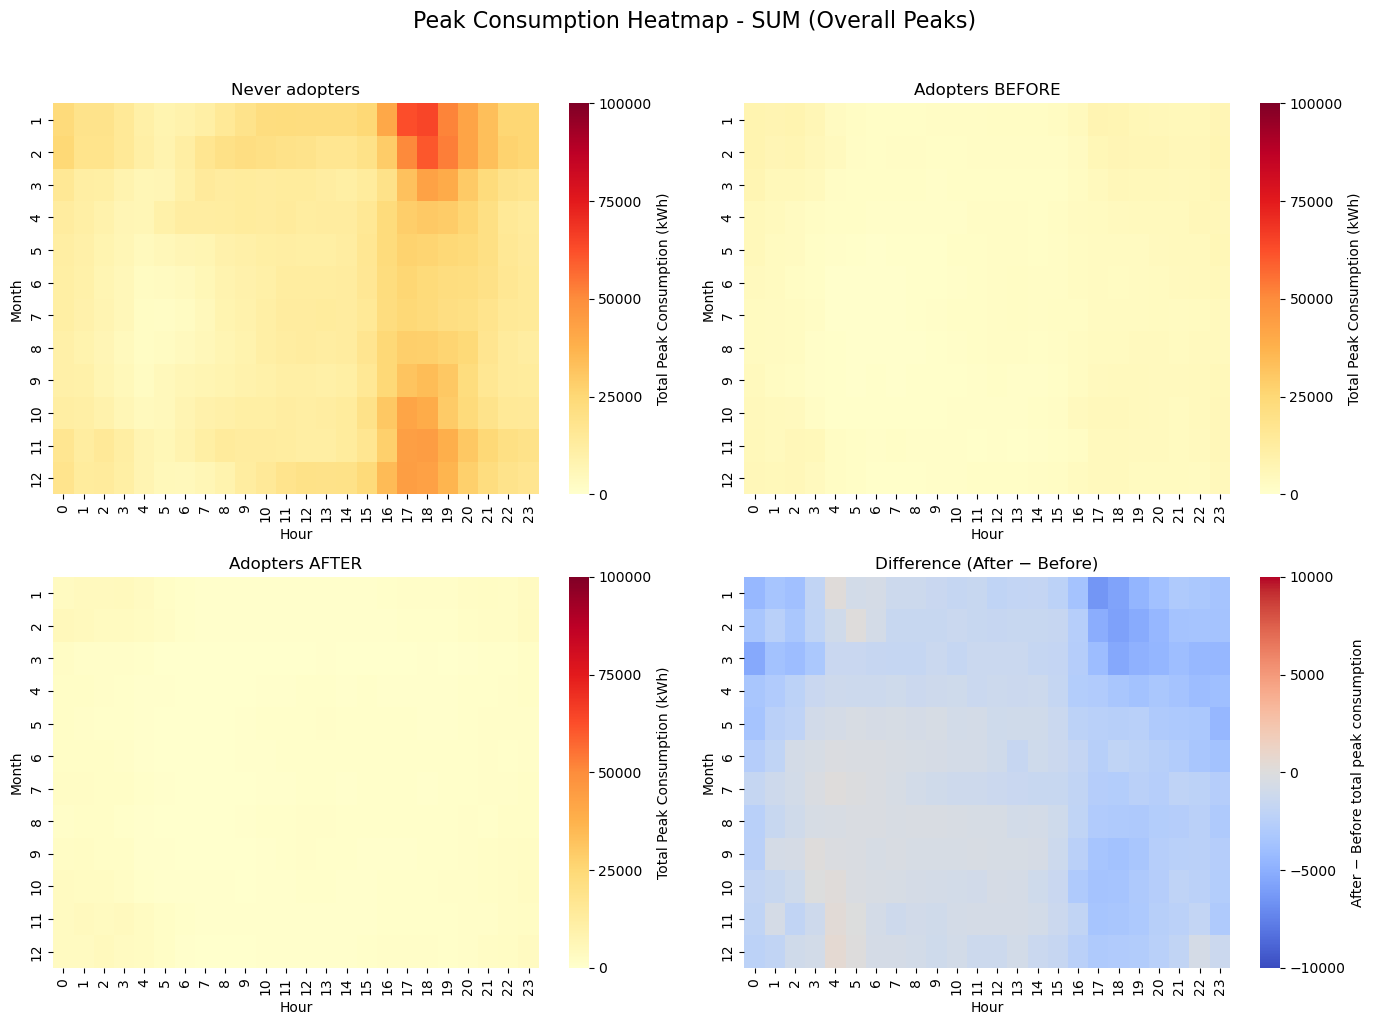

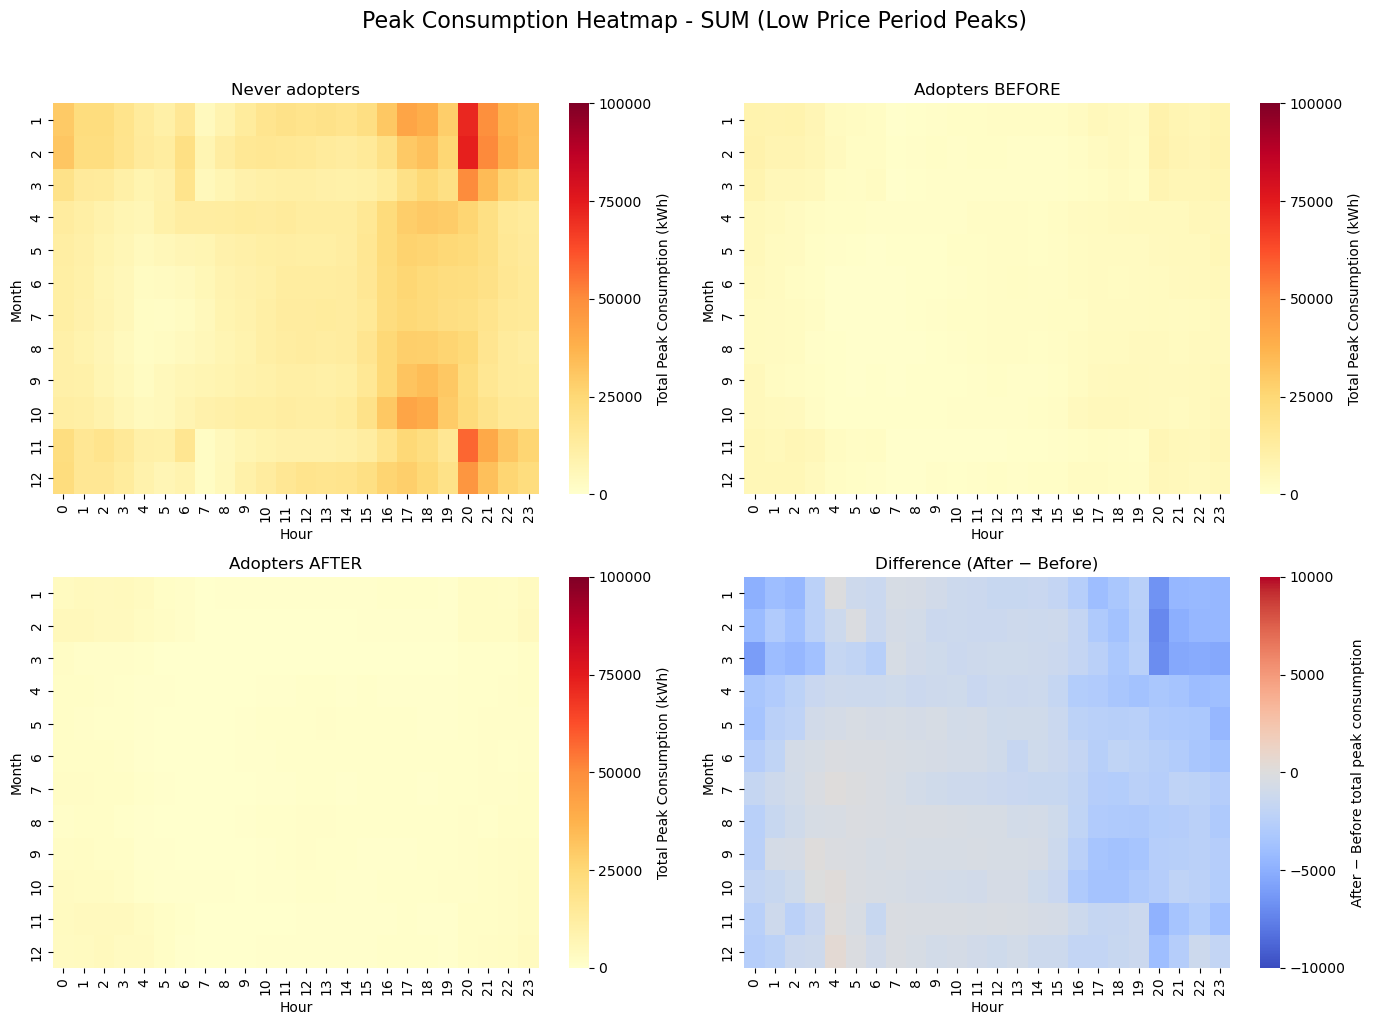

In [ ]:
# per user sum 混合了observation長度

# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "high"],
#     price_label="high",
#     modes=("sum",)
# )

# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "all"],
#     price_label="all",
#     modes=("sum",)
# )
# ㄋ
# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "low"],
#     price_label="low",
#     modes=("sum",)
# )

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 11, Finished, Available, Finished, False)

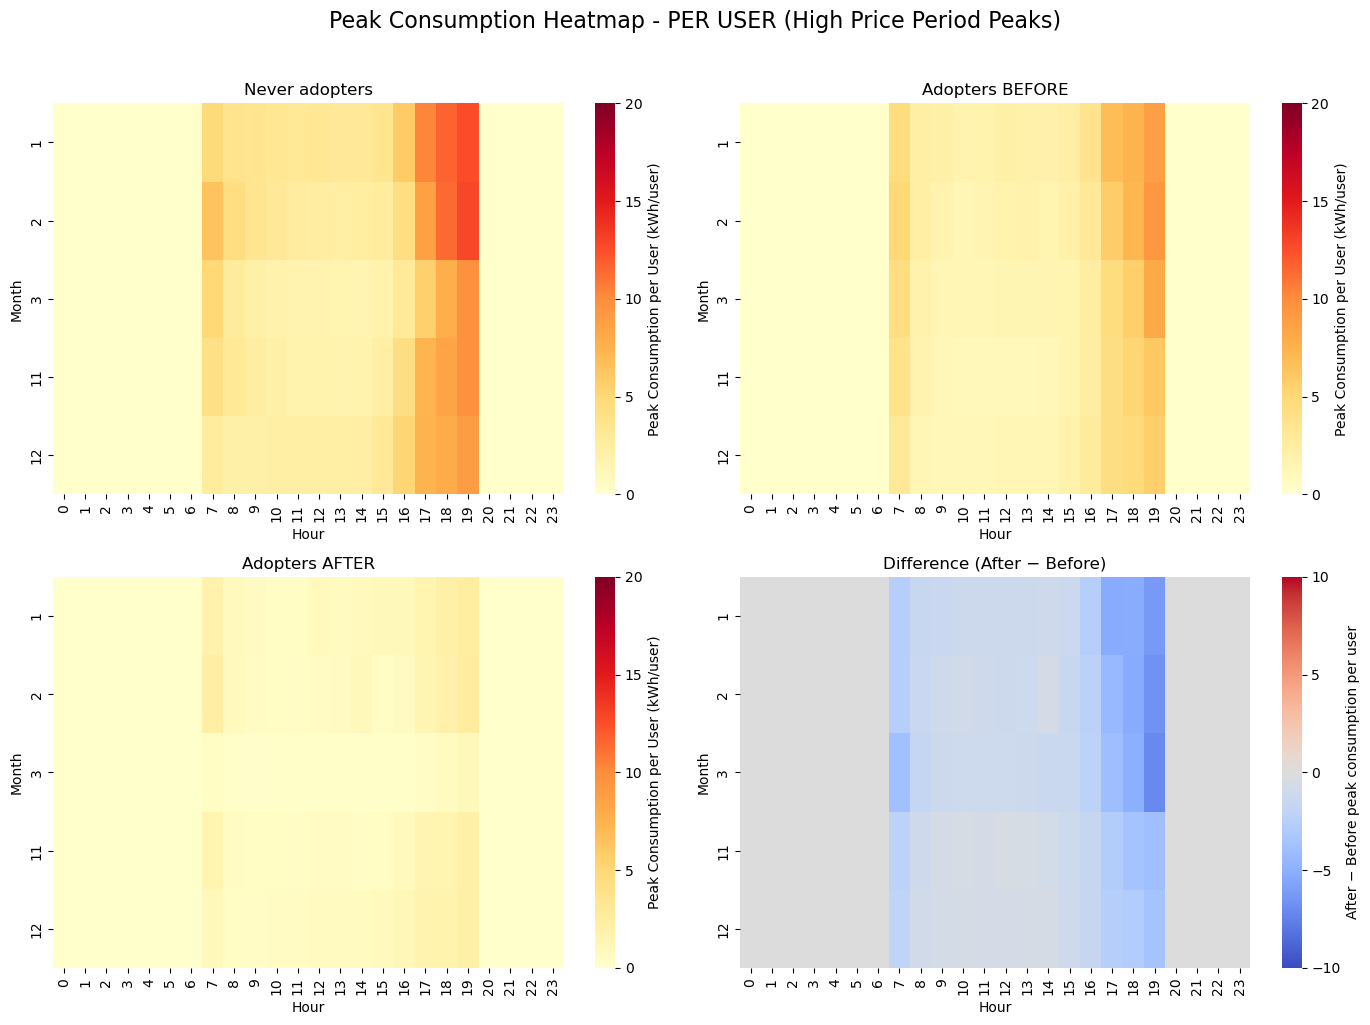

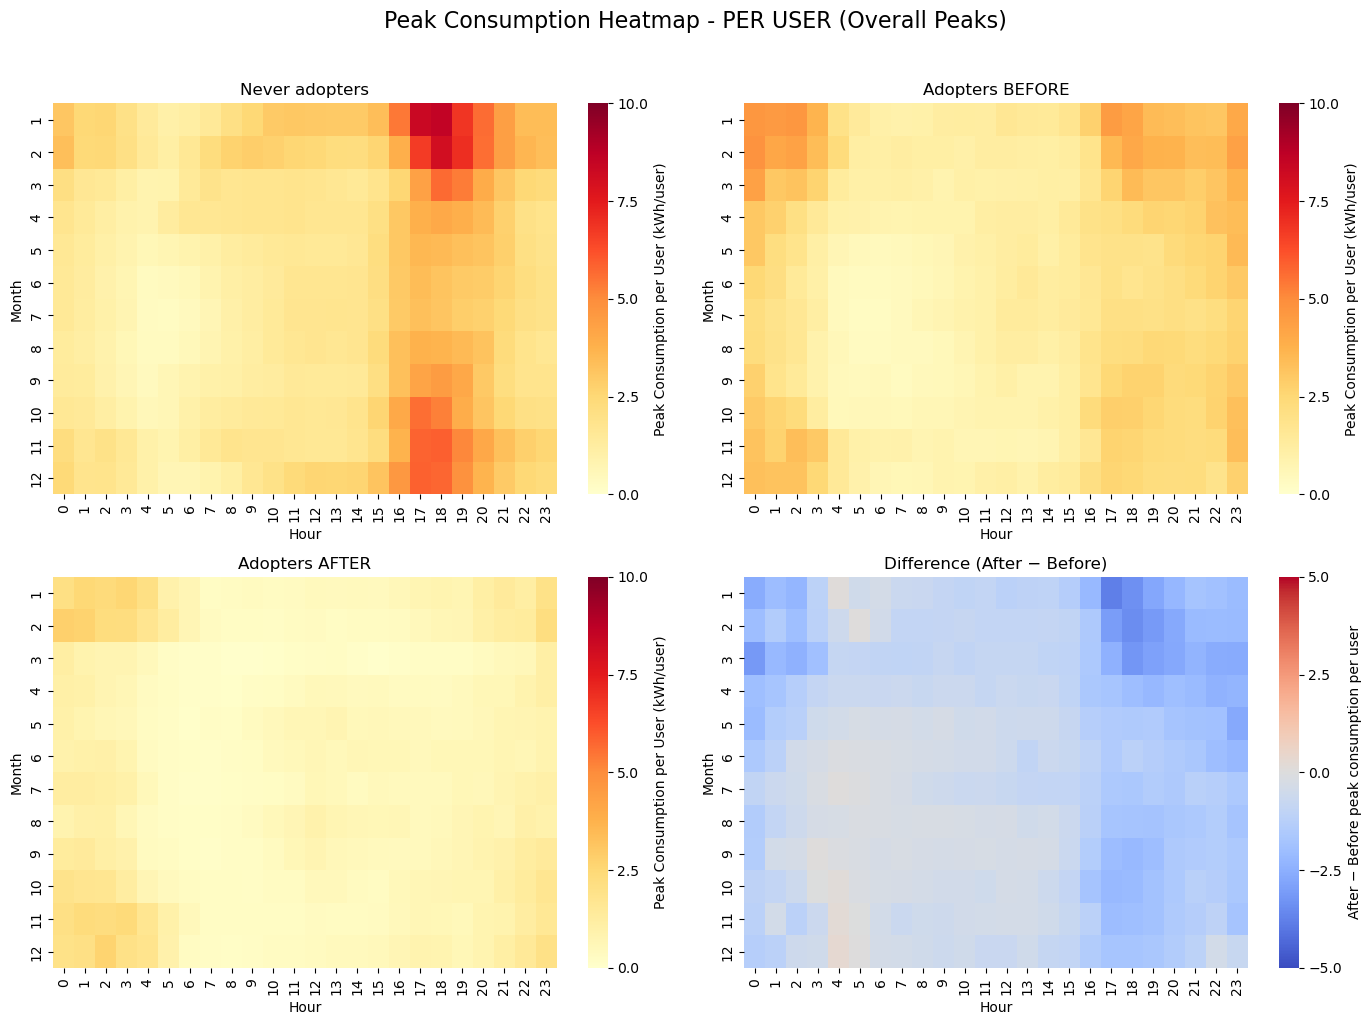

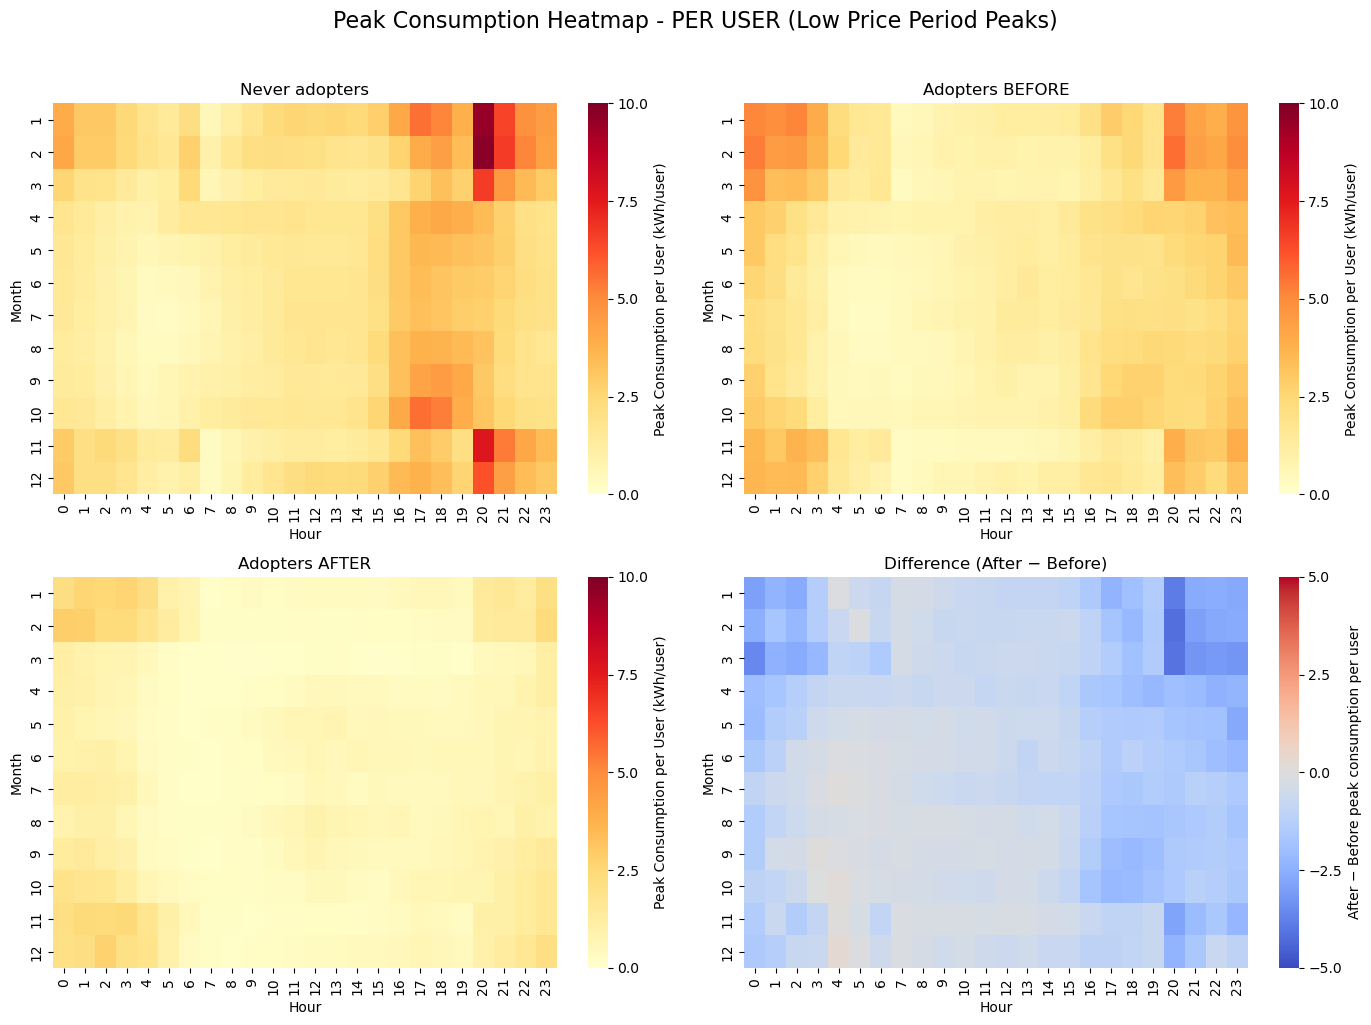

In [ ]:
# per user: sum / users 混合了observation長度

# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "high"],
#     price_label="high",
#     modes=("per_user",)
# )

# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "all"],
#     price_label="all",
#     modes=("per_user",)
# )

# plot_tariff_consumption_heatmap(
#     month_result_matched[month_result_matched["price"] == "low"],
#     price_label="low",
#     modes=("per_user",)
# )

In [ ]:
# 平均每戶每月在這個 cell 貢獻多少 peak consumption？

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "high"],
    price_label="high",
    modes=("per_user_month",)
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "all"],
    price_label="all",
    modes=("per_user_month",)
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "low"],
    price_label="low",
    modes=("per_user_month",)
)

In [ ]:
# Peak frequency per household-month

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "high"],
    price_label="high",
    modes=("frequency",)
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "all"],
    price_label="all",
    modes=("frequency",)
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "low"],
    price_label="low",
    modes=("frequency",)
)

In [ ]:
df_all_full

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, -1, Cancelled, , Cancelled, True)

StatementMeta(, b0582ed2-8a49-4489-a05d-2668503ca560, 12, Finished, Available, Finished, False)

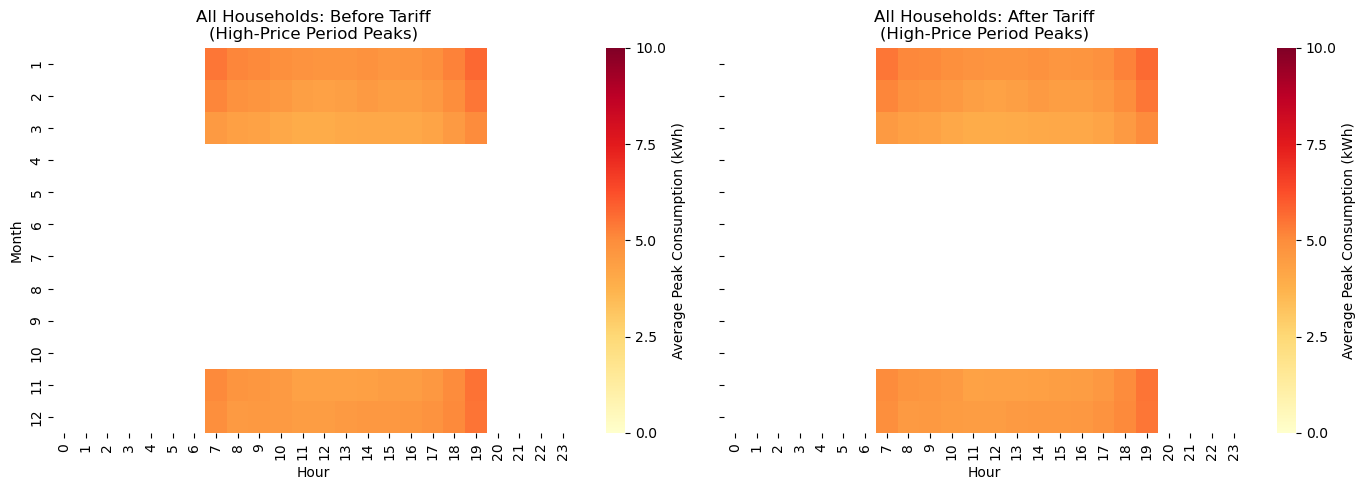

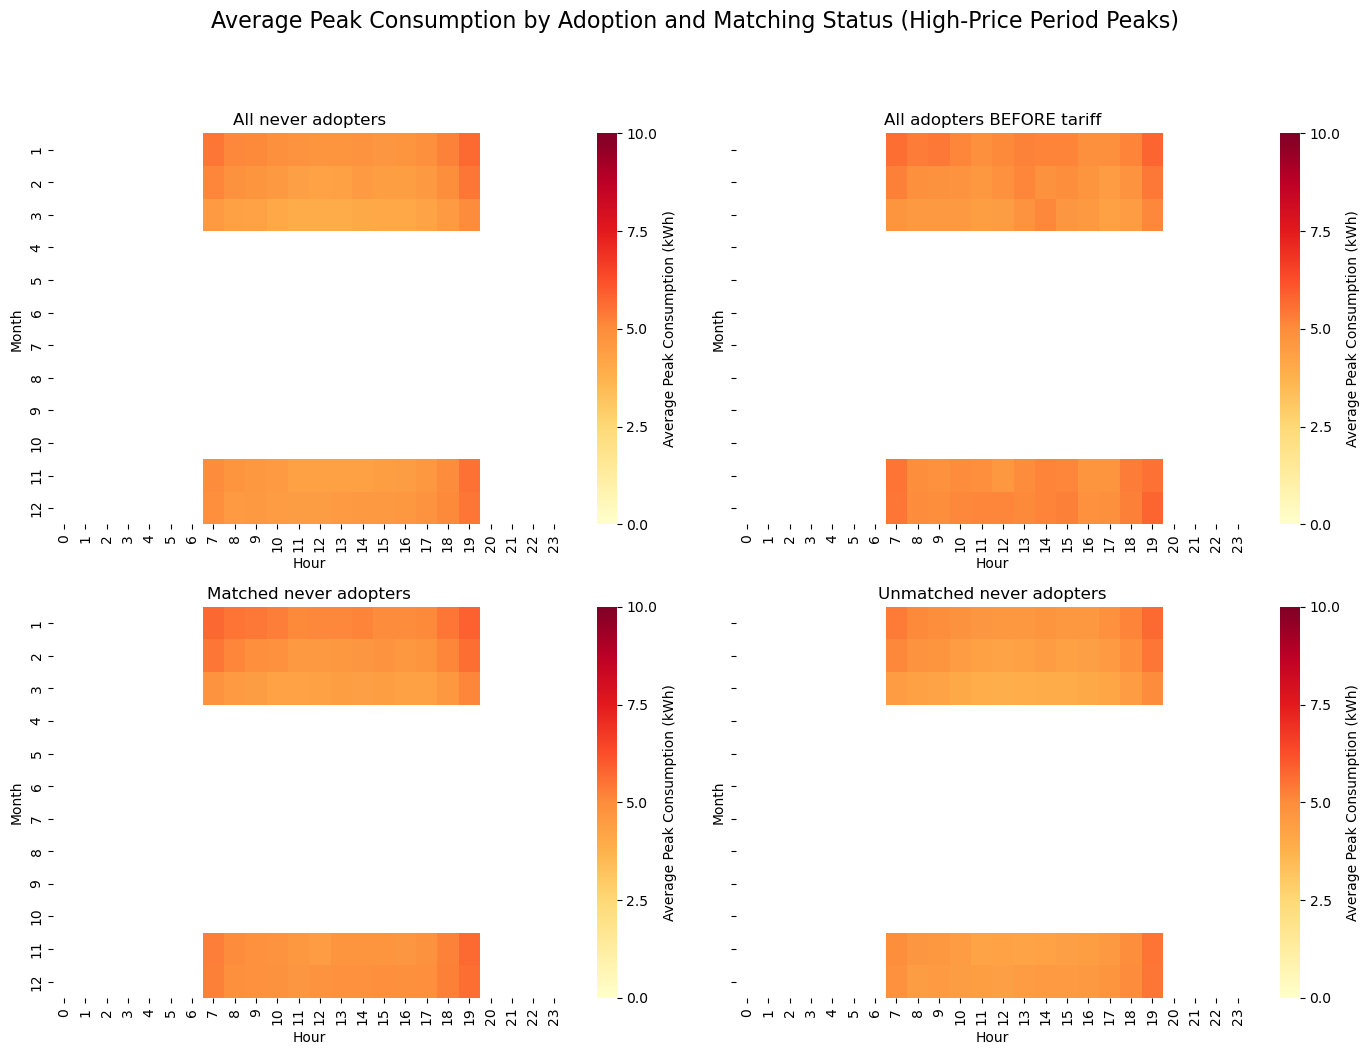

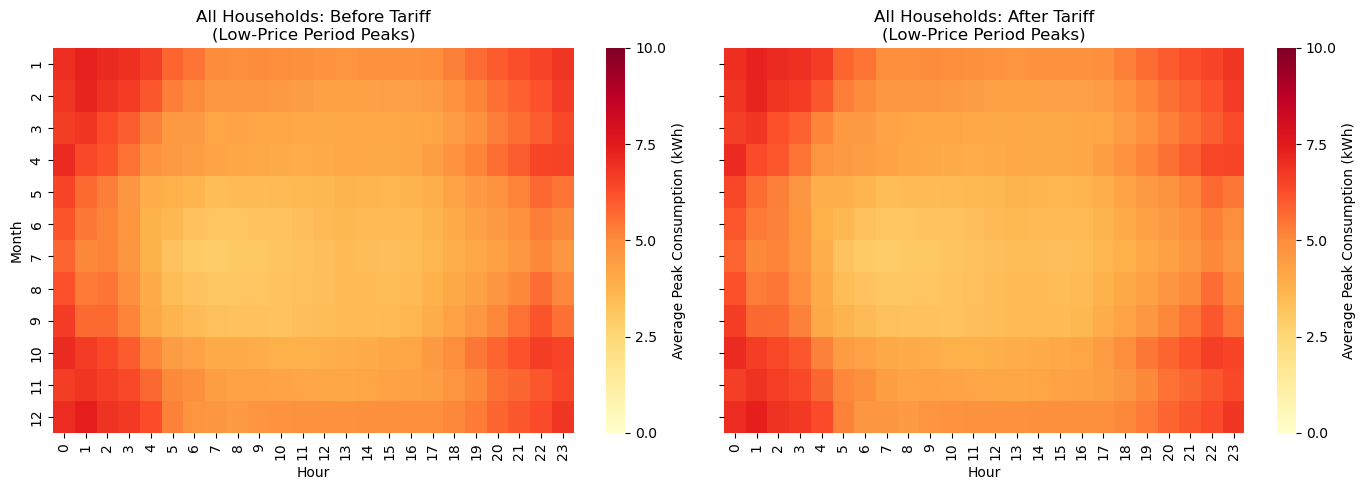

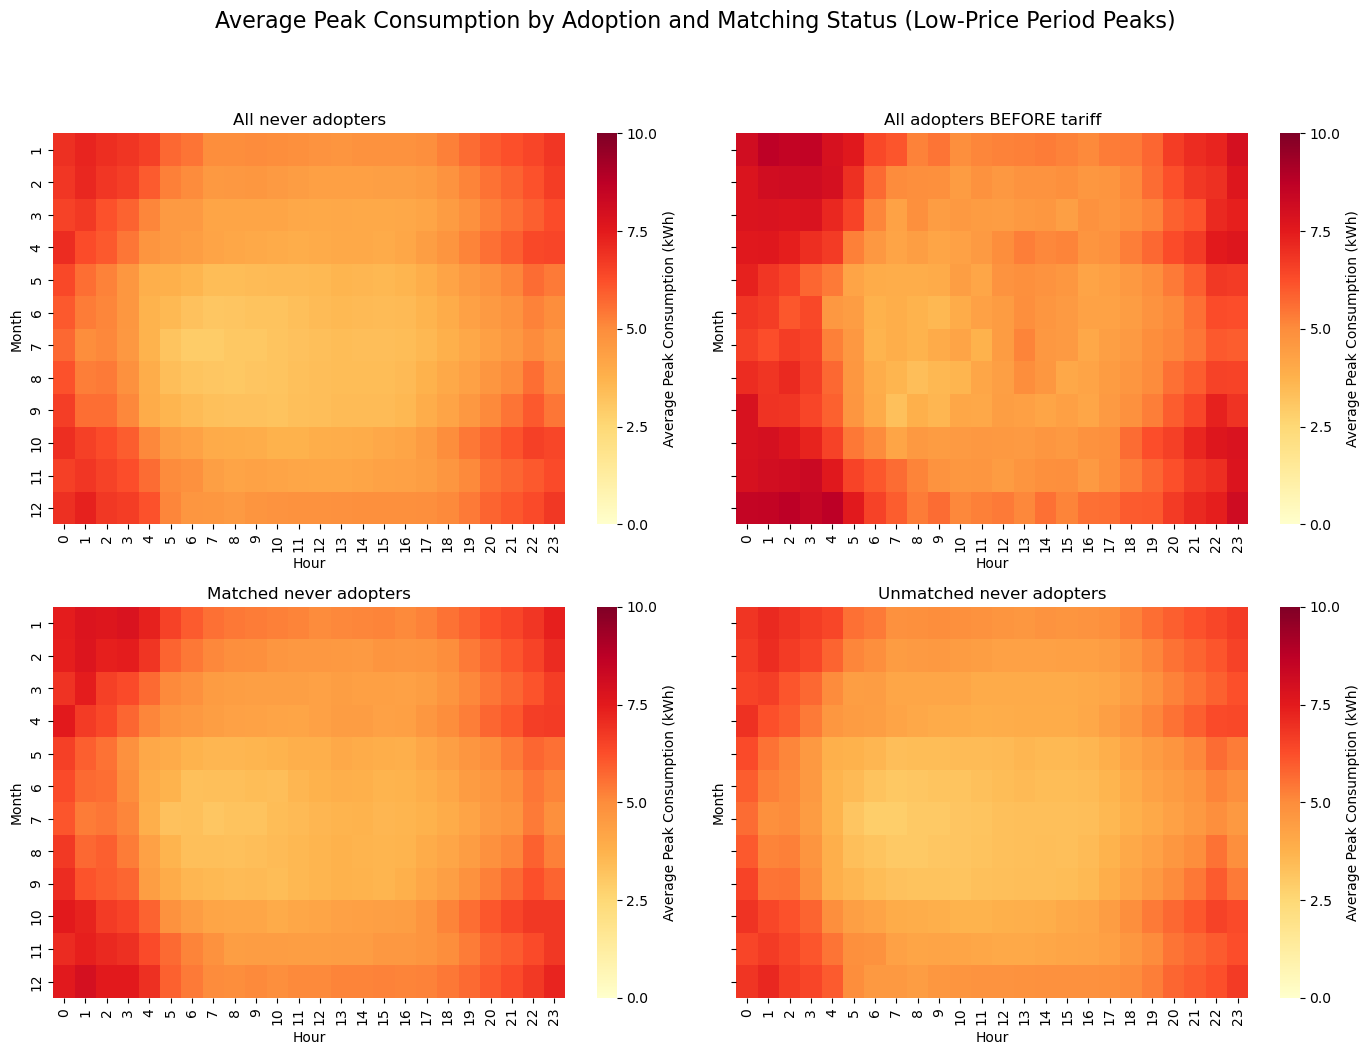

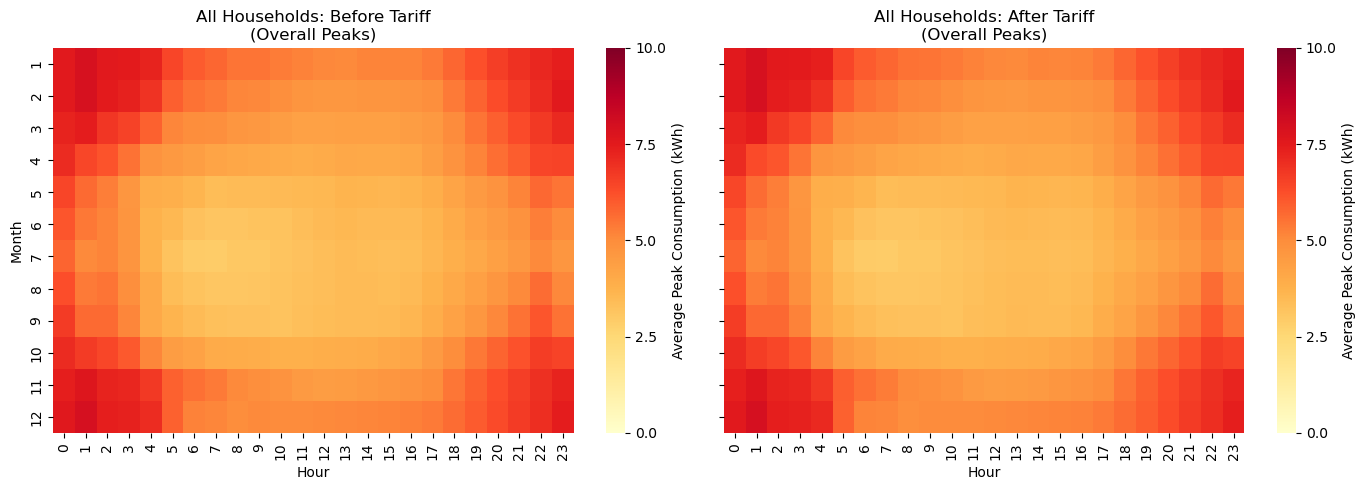

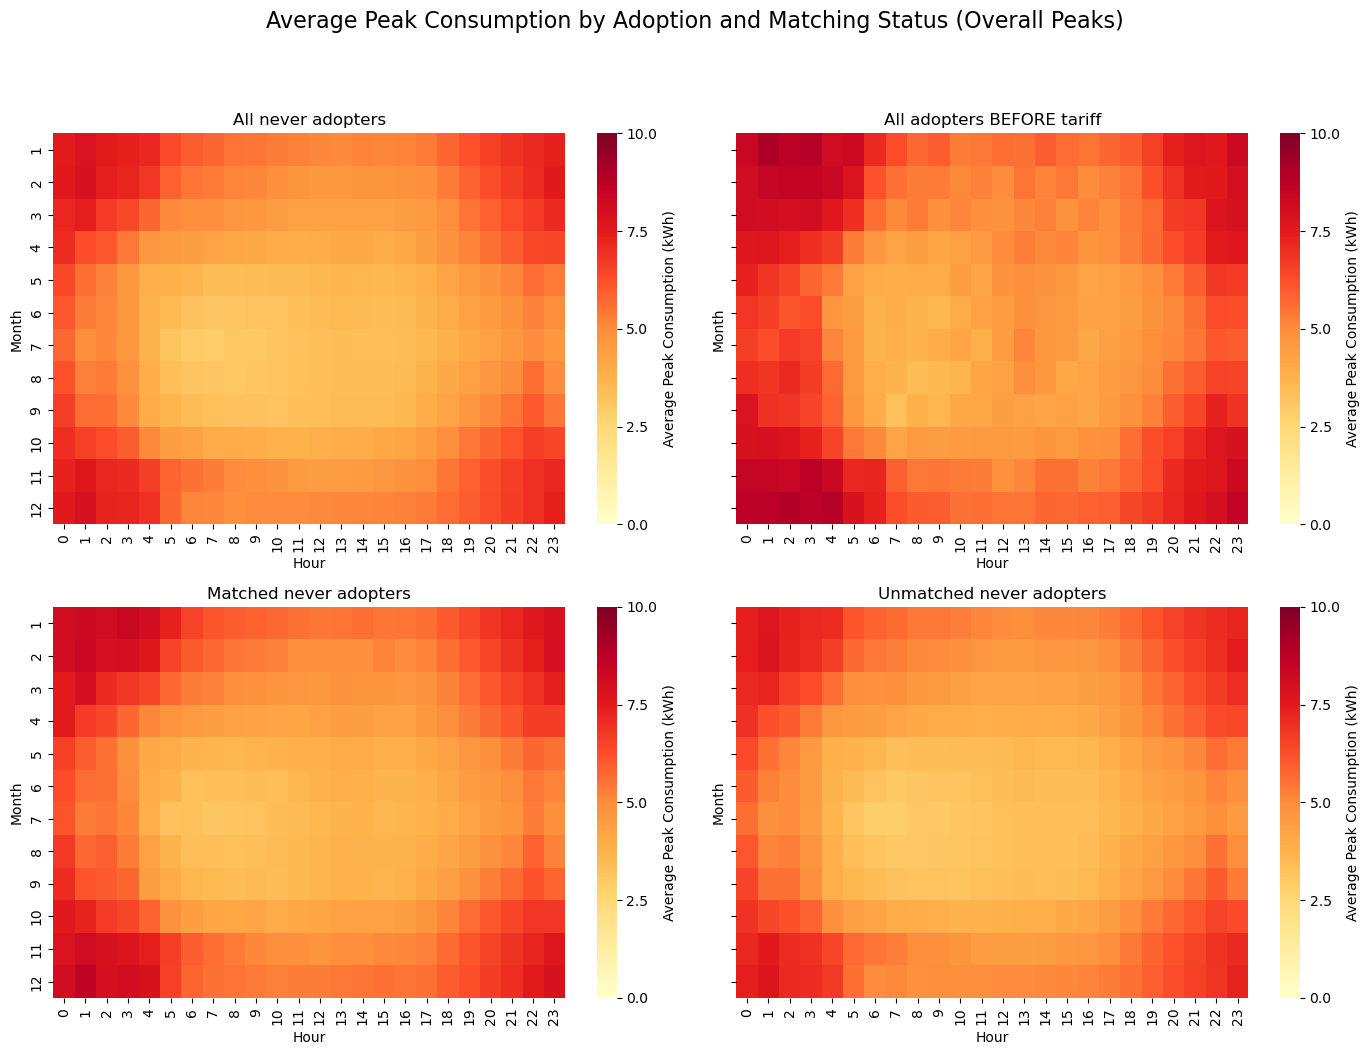

In [ ]:
# 1×2 All households Before/After → sum/month
# 1×4 Matching status → mean, per_user_month, frequency

df_high_full = month_result_full[month_result_full["price"] == "high"].copy()
df_low_full  = month_result_full[month_result_full["price"] == "low"].copy()
df_all_full  = month_result_full[month_result_full["price"] == "all"].copy()

common_vmax_population = get_population_heatmap_common_vmax(
    dfs=[df_high_full, df_low_full, df_all_full],
    matched_control_ids=matched_never_ids
)

for df, label in [
    (df_high_full, "high"),
    (df_low_full, "low"),
    (df_all_full, "all")
]:
    # 1×2: population-level total peak load per month
    # sum/month
    plot_all_households_before_after_heatmap(
        df,
        price_label=label,
        consumption_vmax=common_vmax_population
    )

    # 1×4: matching diagnostics
    for mode in ["mean", "per_user_month", "frequency"]:
        plot_matching_status_heatmaps(
            df,
            matched_control_ids=matched_never_ids,
            price_label=label,
            mode=mode
        )